In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Import data 
df = pd.read_csv(r"C:\Users\user\Downloads\E-Commerce_dataset.csv")
df.head()

,Order_ID,Customer_Name,Email,Order_Date,Ship_Date,Product,Category,Price,Quantity,Total_Amount,Payment_Method,Country,City,Status,Discount
0,1000,Amanda Knight,melissawilliams@jackson-smith.biz,20 Jun 2025,2025-06-25,Smartphone,Electronics,699.99,4,2799.96,Credit Card,Canada,Curtisbury,Shipped,5%
1,1001,Mrs. Lisa Rivera,steven39@hotmail.com,2026-05-03,2026-05-06,Desk Lamp,Home,20,5,100.00,COD,UAE,West Patricia,Cancelled,NaN
2,1002,Brian Meza,asmith@moore.com,16 Jun 2025,NaN,T-shirt,Fashion,9.99,3,29.97,Credit Card,Germany,South Leemouth,Processing,15%
3,1003,Kevin Watson,jacob09@hotmail.com,22-04-2026,2026-04-24,Running Shoes,Fashion,60,1,60.00,PayPal,UK,South Alisha,Shipped,15%
4,1004,Emily Tate,victor94@hotmail.com,21-02-2026,NaN,Backpack,Fashion,45.99,3,137.97,Credit Card,USA,Baileyberg,Cancelled,10%


In [3]:
# Check the data
df.describe # Statistical values
df.isnull().sum() # Missing values


Order_ID             0
Customer_Name      643
Email                0
Order_Date           0
Ship_Date         1195
Product              0
Category             0
Price                0
Quantity             0
Total_Amount       598
Payment_Method       0
Country              0
City                 0
Status               0
Discount          2441
dtype: int64

In [24]:
df.info() # Inspect dataset
df.drop_duplicates(inplace = True) # remove duplicates

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        12000 non-null  int64  
 1   Customer_Name   11357 non-null  str    
 2   Email           12000 non-null  str    
 3   Order_Date      12000 non-null  str    
 4   Ship_Date       10805 non-null  str    
 5   Product         12000 non-null  str    
 6   Category        12000 non-null  str    
 7   Price           12000 non-null  str    
 8   Quantity        12000 non-null  int64  
 9   Total_Amount    11402 non-null  float64
 10  Payment_Method  12000 non-null  str    
 11  Country         12000 non-null  str    
 12  City            12000 non-null  str    
 13  Status          12000 non-null  str    
 14  Discount        9559 non-null   str    
dtypes: float64(1), int64(2), str(12)
memory usage: 1.4 MB


In [25]:
#  Fill the missing values
df["Customer_Name"] = df["Customer_Name"].fillna("Unkknown")
df["Discount"] = df["Discount"].fillna(0)
df["Total_Amount"] = df["Total_Amount"].fillna(0)
df.head()

,Order_ID,Customer_Name,Email,Order_Date,Ship_Date,Product,Category,Price,Quantity,Total_Amount,Payment_Method,Country,City,Status,Discount
0,1000,Amanda Knight,melissawilliams@jackson-smith.biz,20 Jun 2025,2025-06-25,Smartphone,Electronics,699.99,4,2799.96,Credit Card,Canada,Curtisbury,Shipped,5%
1,1001,Mrs. Lisa Rivera,steven39@hotmail.com,2026-05-03,2026-05-06,Desk Lamp,Home,20,5,100.00,COD,UAE,West Patricia,Cancelled,0
2,1002,Brian Meza,asmith@moore.com,16 Jun 2025,NaN,T-shirt,Fashion,9.99,3,29.97,Credit Card,Germany,South Leemouth,Processing,15%
3,1003,Kevin Watson,jacob09@hotmail.com,22-04-2026,2026-04-24,Running Shoes,Fashion,60,1,60.00,PayPal,UK,South Alisha,Shipped,15%
4,1004,Emily Tate,victor94@hotmail.com,21-02-2026,NaN,Backpack,Fashion,45.99,3,137.97,Credit Card,USA,Baileyberg,Cancelled,10%


In [26]:
df["Price"] = pd.to_numeric(df["Price"],errors = "coerce")
df["Price"] = df["Price"].astype(float)
df["Discount"] =pd.to_numeric(df["Discount"],errors ="coerce")
df["Discount"] = df["Discount"].astype(float)

In [53]:
df["Revenue"] = (df["Total_Amount"] * (1 - df["Discount"] / 100)).round(2)

total_revenue= df["Revenue"].sum().round(2)

total_orders = df["Order_ID"].nunique()
total_revenue


np.float64(633179.98)

In [47]:
# Revenue per category
category_revenue = df.groupby("Category")["Revenue"].sum()
category_revenue


Category
Electronics    445565.51
Fashion         67186.47
Furniture       80640.00
Home            37345.00
Stationery       2443.00
Name: Revenue, dtype: float64

In [49]:
# Revenue per product
Top_product = df.groupby("Product")["Revenue"].sum().sort_values(ascending = False)
Top_product

Product
Smartphone        385694.49
Office Chair       80640.00
Running Shoes      35040.00
Headphones         31193.76
Backpack           26352.27
Blender            24045.00
Wireless Mouse     17517.26
Desk Lamp          13300.00
Laptop Sleeve      11160.00
T-shirt             5794.20
Notebook            2443.00
Name: Revenue, dtype: float64

In [48]:

# Revenue by country
country_revenue = df.groupby("Country")["Revenue"].sum()
country_revenue


Country
Brazil      72554.29
Canada      75569.31
China      113752.85
Germany     72585.30
India       66833.87
UAE         80090.88
UK          78232.49
USA         73560.99
Name: Revenue, dtype: float64

In [50]:
# Revenue per customer 
customer_revenue = df.groupby("Customer_Name")["Revenue"].sum()
customer_revenue

Customer_Name
Aaron Ball             0.00
Aaron Conley           0.00
Aaron Conner        2799.96
Aaron Eaton            0.00
Aaron Farley         105.00
                     ...   
Zachary Reid          91.98
Zachary Riggs        137.97
Zachary Roman          0.00
Zachary Thompson     600.00
Zoe Morales            0.00
Name: Revenue, Length: 10560, dtype: float64

In [36]:

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Month"] = pd.to_datetime(df["Order_Date"]).dt.month
df["monthly_sales"] = df.groupby("Month")["Revenue"].mean()

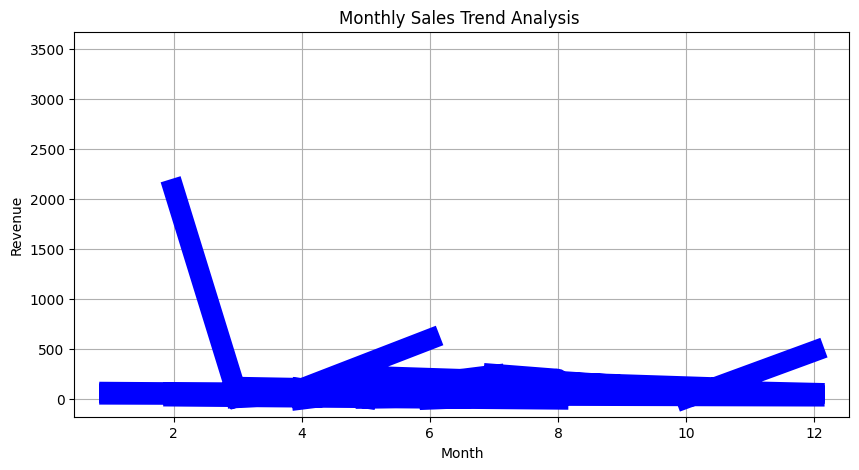

In [69]:
# Monthly Sales Trend Analysis
plt.figure(figsize=(10,5))
plt.plot( 
    df["Month"] ,
    df["Revenue"],
     color = 'Blue',
    linewidth =15,
)
plt.title('Monthly Sales Trend Analysis ')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

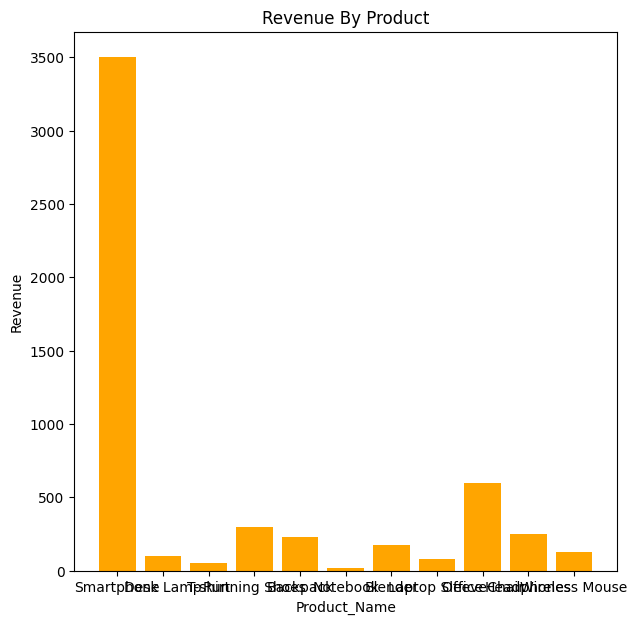

In [57]:
# Revenue by product
plt.figure(figsize=(7,7))
plt.bar(df["Product"],df["Revenue"], color = "Orange")
plt.title('Revenue By Product')
plt.xlabel('Product_Name')
plt.ylabel('Revenue')
plt.show()

<Axes: xlabel='Country', ylabel='Revenue'>

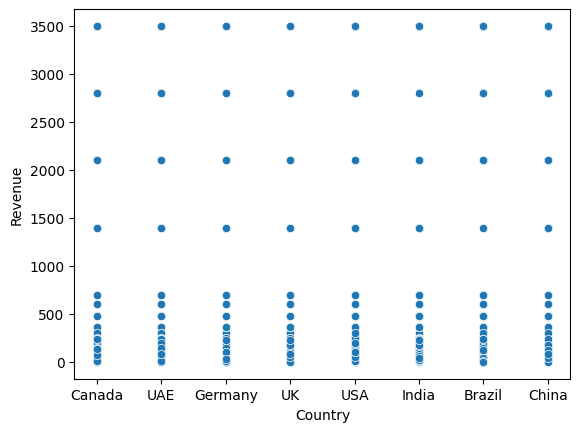

In [63]:
# Revenue by country
x= df["Country"]
y = df["Revenue"]
sns.scatterplot(x= df["Country"],
y = df["Revenue"] )


# Business Insights
1. Electronics category dominates revenue, indicating strong demand and higher ticket size.
2. Smartphones are the top-performing product, suggesting a focused opportunity for inventory and marketing.
3. Brazil generates the highest revenue, making it a key geographic market.
4. Top customers (e.g., Aaron Conley) contribute disproportionately → potential for loyalty programs or premium targeting.
5.March generated the highest contribution to overall revenue compared to other months.